In [1]:
using Clapeyron, Metaheuristics, Printf

In [6]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
24dimethylpentane,100.2,3.0871645,4.005600348,238.6733339,0,0
"""
#3.1426,3.925,238.91,0,0 MOLECULAR
#3.0871645,4.005600348,238.6733339,0,0 GC
unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,24dimethylpentane,0.01
"""

model = PCSAFT(["co2", "24dimethylpentane"], userlocations = [like_parameter, unlike_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 199.23483258884255; 199.23483258884255 238.6733339]
[2.785e-10 3.395300174e-10; 3.395300174e-10 4.005600348e-10]
kij = 0.010000000000000009


In [7]:
function vle_p(model::EoSModel, x_co2::Float64)
    T = 323.15
    try
        # Use experimental pressure range as p0 (11-87 bar from your data)
        p0 = 1e6 + x_co2 * 8e6   # linear from 1 MPa to 9 MPa
        bub = bubble_pressure(model, T, [x_co2, 1-x_co2]; p0=p0)
        return bub[1]
    catch e
        return NaN
    end
end

function vle_y(model::EoSModel, x_co2::Float64)
    T = 323.15
    try
        p0 = 1e6 + x_co2 * 8e6
        bub = bubble_pressure(model, T, [x_co2, 1-x_co2]; p0=p0)
        return bub[4][1]
    catch e
        return NaN
    end
end

vle_y (generic function with 1 method)

In [8]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 100.0,
        :upper   => 250.0,
        :guess   => 199.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 250.0, :param => :epsilon, :indices => (1, 2), :guess => 199.0, :lower => 100.0)

In [9]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_24dimethylpentane.csv")
fix_line_endings("vley_24dimethylpentane.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_24dimethylpentane.csv"
        "vley_24dimethylpentane.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_24dimethylpentane.csv
Fixed: vley_24dimethylpentane.csv
Initial objective value: 0.10076699385432972


In [10]:
method = ECA(; options = Options(iterations = 10000, seed = 999))

params_opt, model_opt = optimize(objective, estimator, method)

([180.9586195429803], PCSAFT{BasicIdeal, Float64}("co2", "24dimethylpentane"))

In [11]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 180.9586195429803; 180.9586195429803 238.6733339]
[2.785e-10 3.395300174e-10; 3.395300174e-10 4.005600348e-10]
kij = 0.10081469680928123


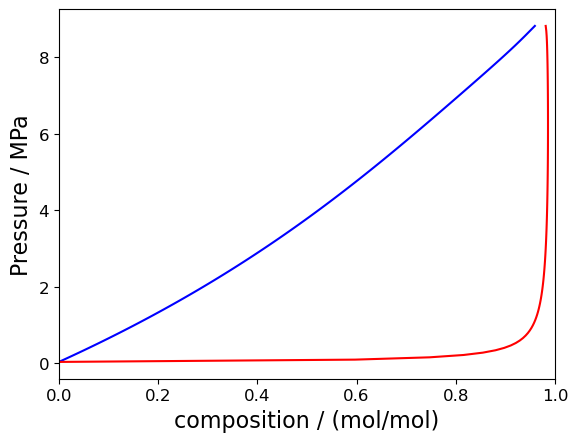

([-2.0, 0.0, 2.0, 4.0, 6.0, 8.0, 10.0], PyCall.PyObject[PyObject Text(0, -2.0, '−2'), PyObject Text(0, 0.0, '0'), PyObject Text(0, 2.0, '2'), PyObject Text(0, 4.0, '4'), PyObject Text(0, 6.0, '6'), PyObject Text(0, 8.0, '8'), PyObject Text(0, 10.0, '10')])

In [12]:
import PyPlot; const plt = PyPlot

N    = 100
T    = 323.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
    p[i] = bub[1]
    y[i] = bub[4][1]
end

plt.clf()
plt.plot(x, p./1e6, color="blue")
plt.plot(y, p./1e6, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Pressure / MPa",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [13]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [14]:
aard_p   = calculate_AAD(model_opt, "vlep_24dimethylpentane.csv", vle_p)


=== AAD: vlep_24dimethylpentane.csv ===

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



Clapeyron Estimator  exp           calc          ARD%    
0.1825      1160000.000000  1208284.637666  4.1625  
0.2980      2050000.000000  2056476.310328  0.3159  
0.4143      3070000.000000  3010264.749405  1.9458  
0.5214      4060000.000000  3985702.032526  1.8300  
0.6238      5030000.000000  5006730.741307  0.4626  
0.7224      6050000.000000  6061229.361435  0.1856  
0.7981      7050000.000000  6903032.132071  2.0847  
0.8791      8050000.000000  7823986.101277  2.8076  
0.9755      8670000.000000  8968024.039724  3.4374  
AARD = 1.9147%


1.9146746098228087

In [15]:
aard_p   = calculate_AAD(model_opt, "vley_24dimethylpentane.csv", vle_y)


=== AAD: vley_24dimethylpentane.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1825      0.973600      0.962517      1.1384  
0.2980      0.981500      0.975778      0.5830  


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


0.4143      0.987400      0.981490      0.5986  
0.5214      0.989400      0.984210      0.5245  
0.6238      0.990800      0.985579      0.5270  
0.7224      0.990400      0.986068      0.4374  
0.7981      0.983200      0.985921      0.2767  
0.8791      0.974100      0.985119      1.1312  
0.9755      0.975500      0.975508      0.0008  
AARD = 0.5797%


0.5797373245735432